# Customer Satisfaction Prediction

###
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building
5. Model Evaluation
6. Visualization

In [81]:
import pandas as pd             #data handling
import numpy as np              #numeric compuctation /value
import matplotlib.pyplot as plt  #Visualization, low level lib
import seaborn as sns             # Visualization, high level lib

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [83]:
# Load the dataset
df= pd.read_csv('Downloads/customer_support_tickets.csv')

In [84]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


### Data Preprocessing

In [85]:
df.isnull().sum()  # check all column for missing

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [86]:
#data = data.dropna()   # remove the missing data

In [87]:
# Convert Time to Resolution to duration (example: hours)
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution']) - pd.to_datetime(df['Date of Purchase'])
df['Time to Resolution'] = df['Time to Resolution'].dt.total_seconds() / 3600  # convert to hours

# Fill missing values for Resolution with a placeholder
df['Resolution'] = df['Resolution'].fillna('Not Provided')

# Fill missing values for Customer Satisfaction Rating with median
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].fillna(df['Customer Satisfaction Rating'].median())

In [88]:
# Calculate First Response Time duration in hours
df['First Response Time'] = (pd.to_datetime(df['First Response Time']) - pd.to_datetime(df['Date of Purchase'])).dt.total_seconds() / 3600

# Calculate Time to Resolution duration in hours
df['Time to Resolution'] = (pd.to_datetime(df['Time to Resolution']) - pd.to_datetime(df['Date of Purchase'])).dt.total_seconds() / 3600

# Fill missing durations with the median
df['First Response Time'] = df['First Response Time'].fillna(df['First Response Time'].median())
df['Time to Resolution'] = df['Time to Resolution'].fillna(df['Time to Resolution'].median())


In [89]:
df.isnull().sum()

Ticket ID                       0
Customer Name                   0
Customer Email                  0
Customer Age                    0
Customer Gender                 0
Product Purchased               0
Date of Purchase                0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Status                   0
Resolution                      0
Ticket Priority                 0
Ticket Channel                  0
First Response Time             0
Time to Resolution              0
Customer Satisfaction Rating    0
dtype: int64

### Exploratory Data Analysis (EDA)

In [90]:
# Display basic info about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    8469 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [91]:
df.describe()

,Ticket ID,Customer Age,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469.000000,8469.000000,8469.000000,8469.000000
mean,4235.000000,44.026804,21246.357367,-446949.228480,2.997166
std,2444.934048,15.296112,4153.525612,2902.199714,0.804446
min,1.000000,18.000000,12435.146111,-455784.000000,1.000000
25%,2118.000000,31.000000,18999.181667,-446928.000000,3.000000
50%,4235.000000,44.000000,21273.225972,-446928.000000,3.000000
75%,6352.000000,57.000000,23514.268056,-446928.000000,3.000000
max,8469.000000,70.000000,29944.581944,-438288.000000,5.000000


In [92]:
df.shape

(8469, 17)

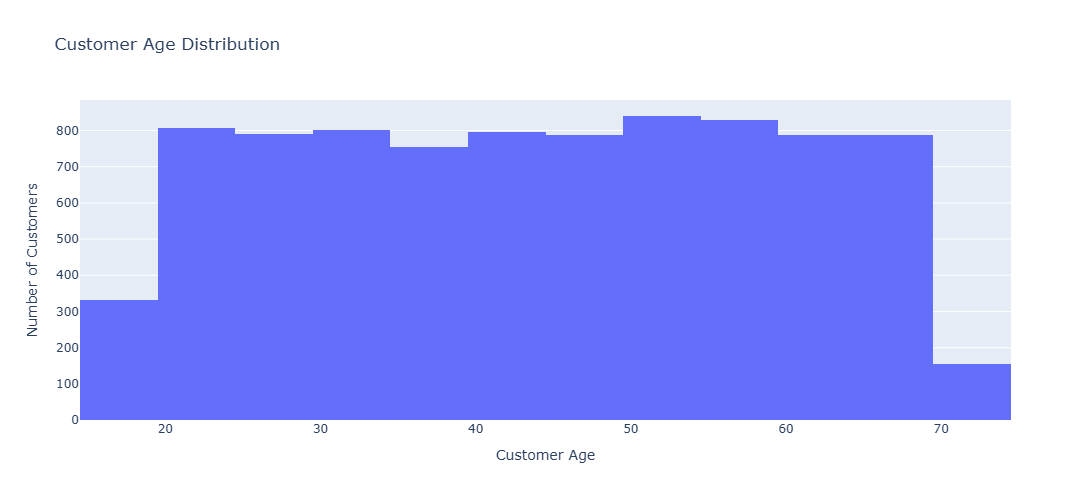

In [93]:
import plotly.express as px

fig = px.histogram(
    df,
    x='Customer Age',
    nbins=20,
    title='Customer Age Distribution',
    height=500
)

fig.update_layout(
    xaxis_title='Customer Age',
    yaxis_title='Number of Customers'
)

fig.show()

In [94]:
df['Date of Purchase']

0       2021-03-22
1       2021-05-22
2       2020-07-14
3       2020-11-13
4       2020-02-04
           ...    
8464    2021-12-08
8465    2020-02-22
8466    2021-08-17
8467    2021-10-16
8468    2020-06-01
Name: Date of Purchase, Length: 8469, dtype: object

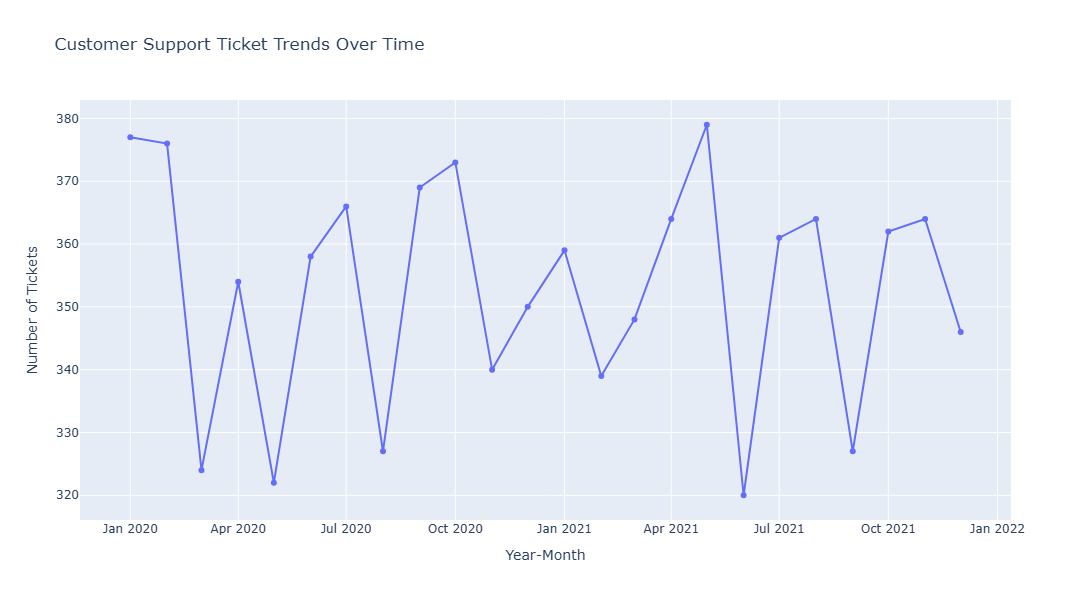

In [95]:
# Convert date column
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['YearMonth'] = df['Date of Purchase'].dt.to_period('M').astype(str)

# Group data
ticket_trends = (
    df.groupby('YearMonth')
    .size()
    .reset_index(name='Number of Tickets')
)

# Plot with increased height
fig = px.line(
    ticket_trends,
    x='YearMonth',
    y='Number of Tickets',
    markers=True,
    title='Customer Support Ticket Trends Over Time',
    height=600   # 👈 increased height
)

fig.update_layout(
    xaxis_title='Year-Month',
    yaxis_title='Number of Tickets',
    hovermode='x unified'
)

fig.show()


In [96]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors='coerce')

df['YearMonth'] = df['Date of Purchase'].dt.to_period('M').dt.to_timestamp()

ticket_trends = (
    df.groupby('YearMonth')
    .size()
    .reset_index(name='Number of Tickets')
    .sort_values('YearMonth')
)

In [97]:
top_issues = (
    df["Ticket Subject"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_issues.columns = ["Ticket Subject", "Count"]

top_issues

,Ticket Subject,Count
0,Refund request,576
1,Software bug,574
2,Product compatibility,567
3,Delivery problem,561
4,Hardware issue,547
5,Battery life,542
6,Network problem,539
7,Installation support,530
8,Product setup,529
9,Payment issue,526


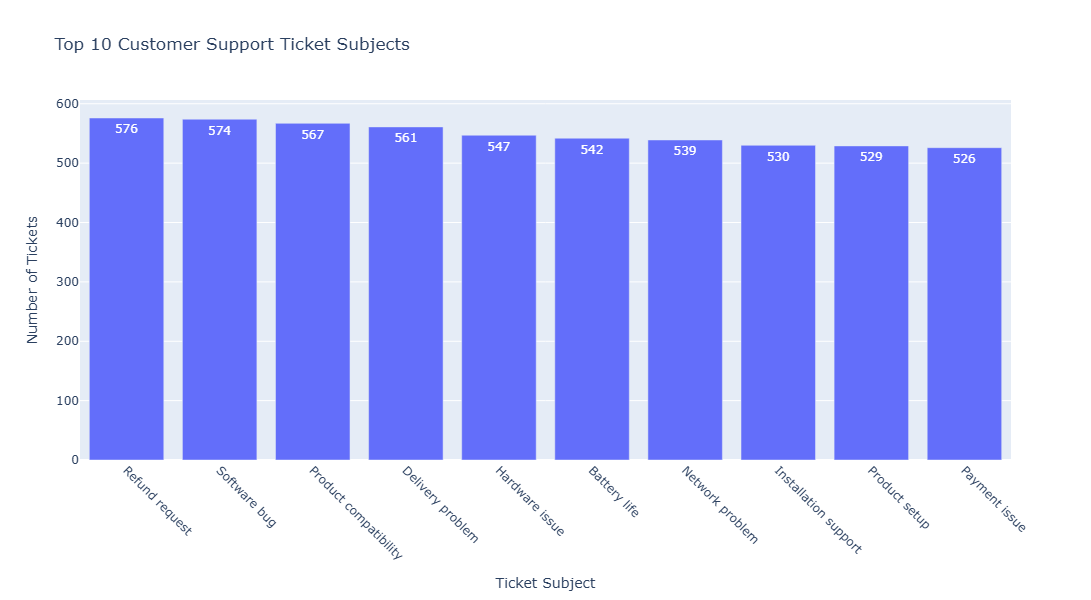

In [98]:
top_issues_df = top_issues.copy()
top_issues_df.columns = ['Ticket Subject', 'Number of Tickets']

fig = px.bar(
    top_issues_df,
    x='Ticket Subject',
    y='Number of Tickets',
    title='Top 10 Customer Support Ticket Subjects',
    text='Number of Tickets',
    height=600
)

fig.update_layout(
    xaxis_title='Ticket Subject',
    yaxis_title='Number of Tickets',
    xaxis_tickangle=45
)

fig.show()

In [99]:
df['Ticket Type'].value_counts().head(10)


Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

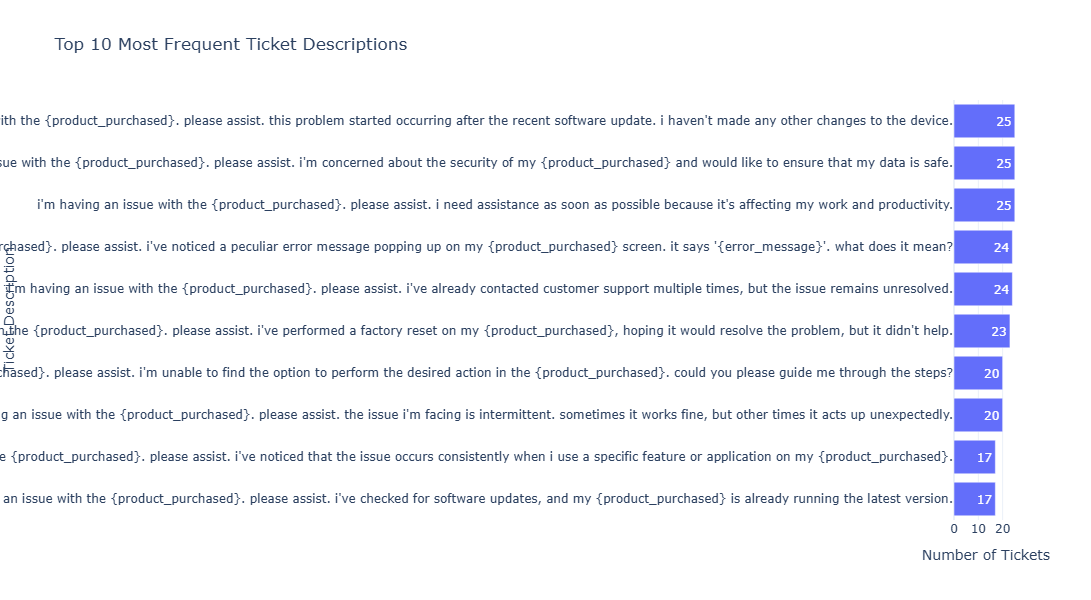

In [100]:
# Handle missing values properly and clean text
df['Ticket Description'] = (
    df['Ticket Description']
    .fillna('No Description')   # Replace NaN safely
    .astype(str)
    .str.lower()
    .str.strip()
)

# Get top 10 most frequent descriptions
top_desc = (
    df['Ticket Description']
    .value_counts()
    .head(10)
    .reset_index()
)

top_desc.columns = ['Ticket Description', 'Count']

# Plot horizontal bar chart
import plotly.express as px

fig = px.bar(
    top_desc,
    x='Count',
    y='Ticket Description',
    orientation='h',
    title='Top 10 Most Frequent Ticket Descriptions',
    height=600,
    text='Count'
)

fig.update_layout(
    xaxis_title='Number of Tickets',
    yaxis_title='Ticket Description',
    yaxis=dict(autorange='reversed'),
    template='plotly_white'
)

fig.show()

In [101]:

# Segment customers based on Ticket Type
ticket_type_segmentation = df.groupby('Ticket Type').size()
ticket_type_segmentation


Ticket Type
Billing inquiry         1634
Cancellation request    1695
Product inquiry         1641
Refund request          1752
Technical issue         1747
dtype: int64

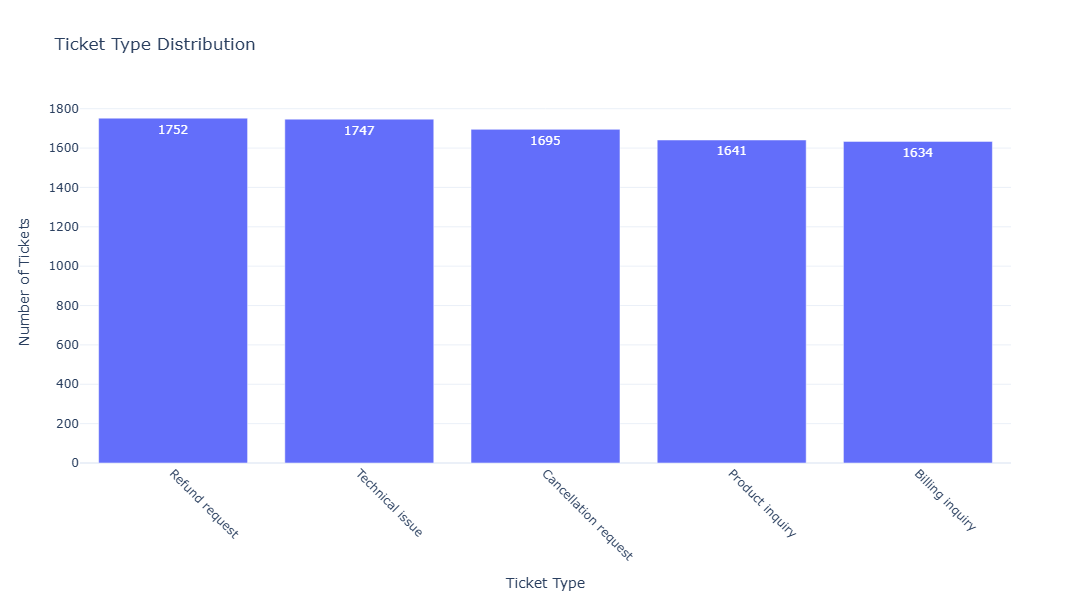

In [102]:
# If ticket_type_segmentation is already a Series from groupby().size()
ticket_type_df = (
    ticket_type_segmentation
    .reset_index(name='Number of Tickets')
    .sort_values('Number of Tickets', ascending=False)
)

# Plot
import plotly.express as px

fig = px.bar(
    ticket_type_df,
    x='Ticket Type',
    y='Number of Tickets',
    title='Ticket Type Distribution',
    text='Number of Tickets',
    height=600
)

fig.update_layout(
    xaxis_title='Ticket Type',
    yaxis_title='Number of Tickets',
    xaxis_tickangle=45,
    template='plotly_white'
)

fig.show()

In [103]:
top_5_ticket_types = ticket_type_segmentation.sort_values(ascending=False).head(5)
top_5_ticket_types


Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
dtype: int64

In [104]:
# Segment based on customer satisfaction rating
satisfaction_segmentation = (
    df.groupby('Customer Satisfaction Rating')
    .size()
    .sort_index()   # ratings 1 → 5 order 
)

satisfaction_segmentation


Customer Satisfaction Rating
1.0     553
2.0     549
3.0    6280
4.0     543
5.0     544
dtype: int64

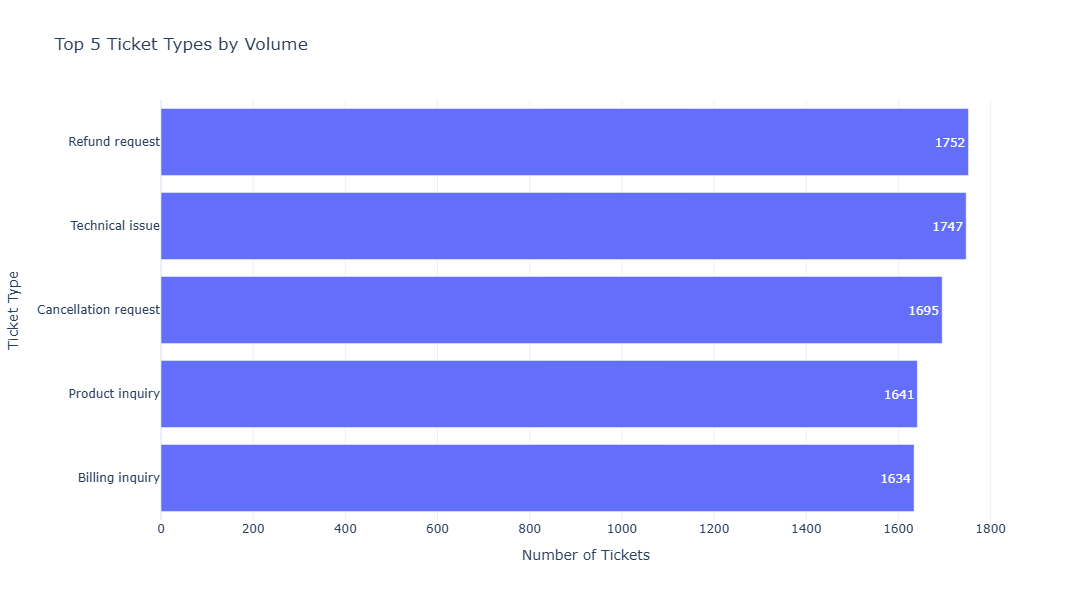

In [105]:
# Create Top 5 ticket types safely
top_5_ticket_types = (
    df['Ticket Type']
    .fillna('Unknown')
    .value_counts()
    .head(5)
)

# Convert to DataFrame properly
top_5_df = top_5_ticket_types.reset_index()
top_5_df.columns = ['Ticket Type', 'Number of Tickets']

# Plot horizontal bar chart
import plotly.express as px

fig = px.bar(
    top_5_df,
    x='Number of Tickets',
    y='Ticket Type',
    orientation='h',
    title='Top 5 Ticket Types by Volume',
    text='Number of Tickets',
    height=600
)

fig.update_layout(
    yaxis=dict(autorange='reversed'),
    template='plotly_white'
)

fig.show()

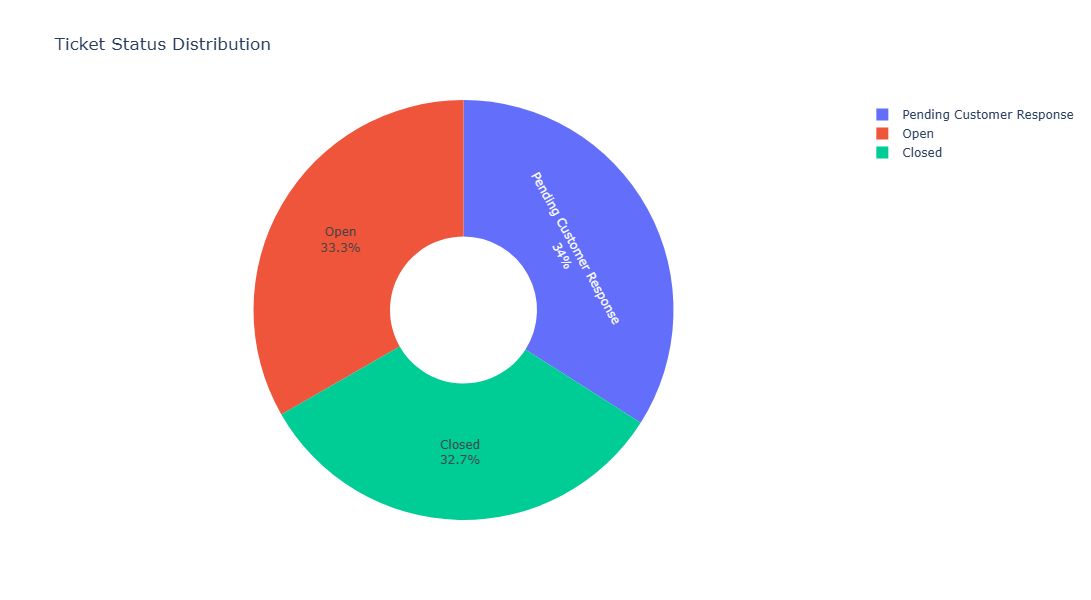

In [106]:
import plotly.express as px

# Ticket status distribution
ticket_status_distribution = df['Ticket Status'].value_counts().reset_index()
ticket_status_distribution.columns = ['Ticket Status', 'Count']

# Plot interactive pie chart
fig = px.pie(
    ticket_status_distribution,
    names='Ticket Status',
    values='Count',
    title='Ticket Status Distribution',
    hole=0.35,        # donut style (looks professional)
    height=600
)

fig.update_traces(
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>Tickets: %{value}<br>Percentage: %{percent}'
)

fig.show()


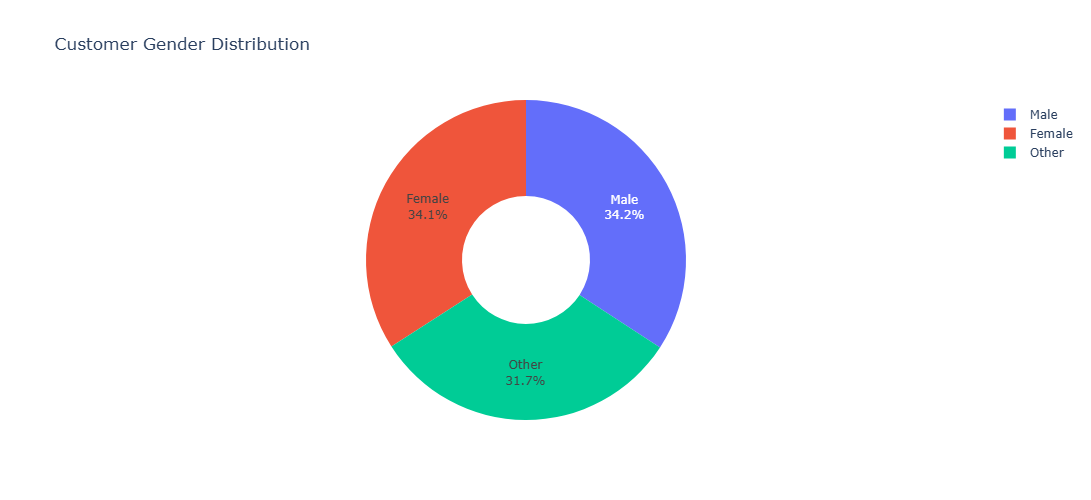

In [107]:

# Gender distribution
gender_dist = df['Customer Gender'].value_counts().reset_index()
gender_dist.columns = ['Gender', 'Count']

# Custom colors
custom_colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

fig = px.pie(
    gender_dist,
    names='Gender',
    values='Count',
    title='Customer Gender Distribution',
    hole=0.4,
    height=500,
    color_discrete_sequence=custom_colors
)

fig.update_traces(
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>Customers: %{value}<br>Percentage: %{percent}'
)

fig.show()


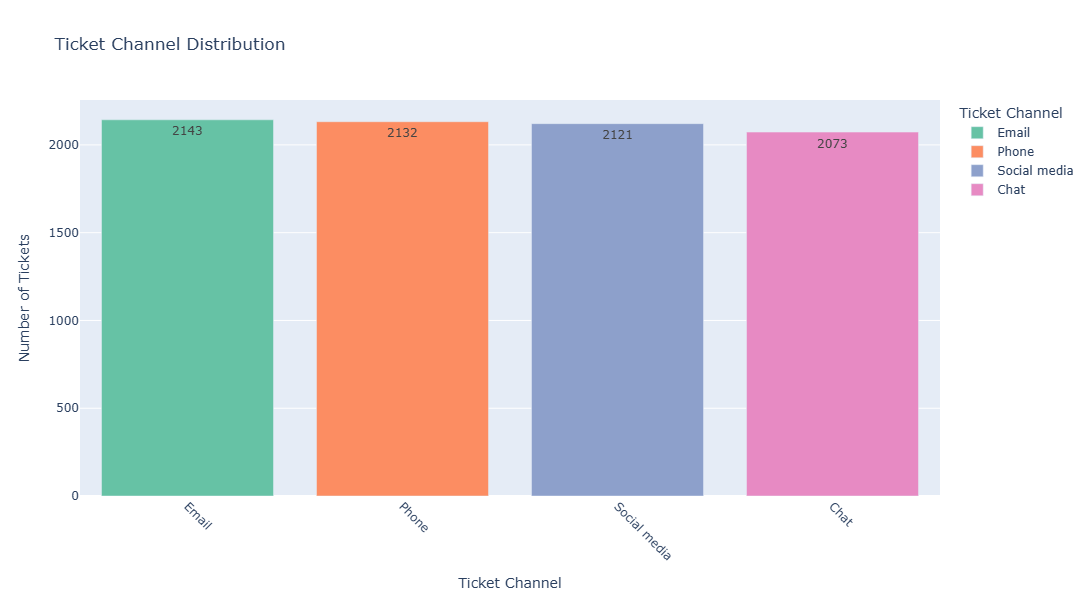

In [108]:
# Ticket channel distribution
channel_dist = df['Ticket Channel'].value_counts().reset_index()
channel_dist.columns = ['Ticket Channel', 'Count']

# Plot
fig = px.bar(
    channel_dist,
    x='Ticket Channel',
    y='Count',
    title='Ticket Channel Distribution',
    text='Count',
    height=600,
    color='Ticket Channel',
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    xaxis_title='Ticket Channel',
    yaxis_title='Number of Tickets',
    xaxis_tickangle=45
)

fig.show()


In [109]:
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')

In [110]:
analysis_df = df[['Ticket Priority', 'Time to Resolution']]
analysis_df.head()


,Ticket Priority,Time to Resolution
0,Critical,-446928.0
1,Critical,-446928.0
2,Low,-442968.0
3,Low,-445896.0
4,Low,-439104.0


In [111]:
df['Time to Resolution'].describe()

count      8469.000000
mean    -446949.228480
std        2902.199714
min     -455784.000000
25%     -446928.000000
50%     -446928.000000
75%     -446928.000000
max     -438288.000000
Name: Time to Resolution, dtype: float64

In [112]:
avg_satisfaction_gender = (
    df.groupby('Customer Gender')['Customer Satisfaction Rating']
    .mean()
    .reset_index()
)


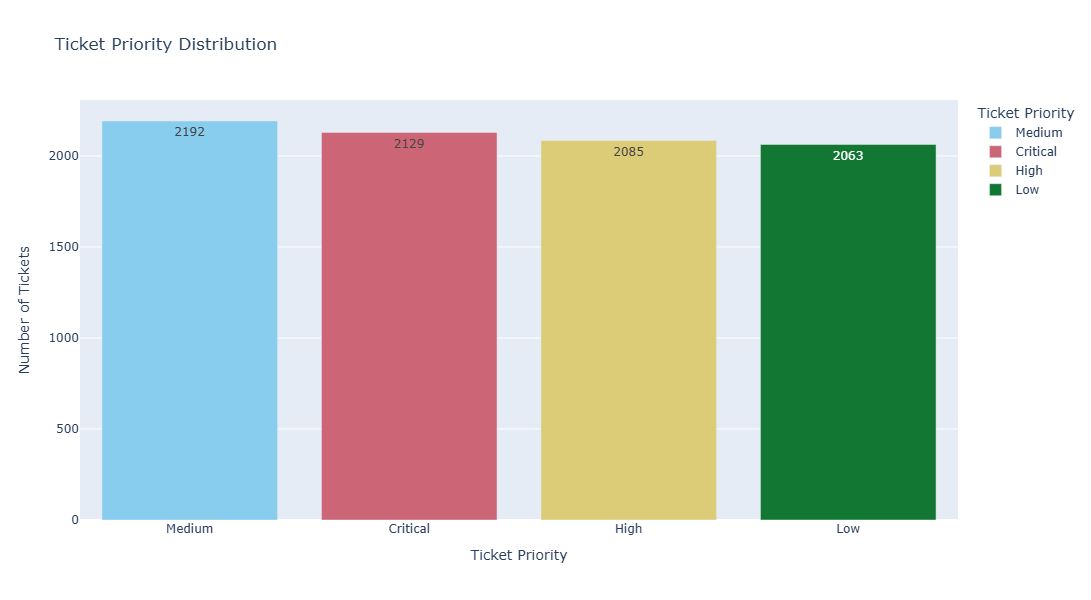

In [113]:
# Ticket Priority distribution
priority_dist = df['Ticket Priority'].value_counts().reset_index()
priority_dist.columns = ['Ticket Priority', 'Count']

# Plot
fig = px.bar(
    priority_dist,
    x='Ticket Priority',
    y='Count',
    title='Ticket Priority Distribution',
    text='Count',
    height=600,
    color='Ticket Priority',
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_layout(
    xaxis_title='Ticket Priority',
    yaxis_title='Number of Tickets'
)

fig.show()


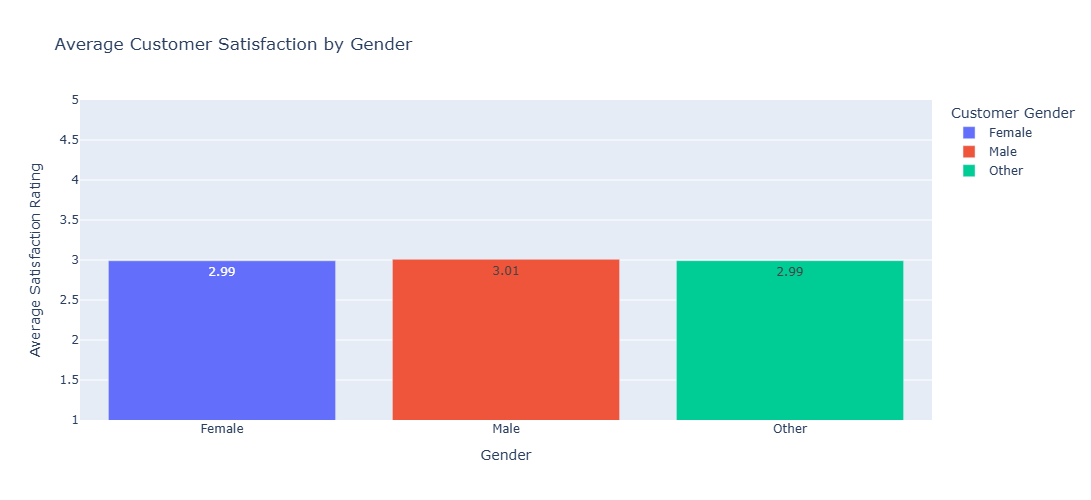

In [114]:
fig = px.bar(
    avg_satisfaction_gender,
    x='Customer Gender',
    y='Customer Satisfaction Rating',
    color='Customer Gender',          # color by gender
    title='Average Customer Satisfaction by Gender',
    text=avg_satisfaction_gender['Customer Satisfaction Rating'].round(2),
    height=500
)

fig.update_layout(
    xaxis_title='Gender',
    yaxis_title='Average Satisfaction Rating',
    yaxis_range=[1, 5]
)

fig.show()


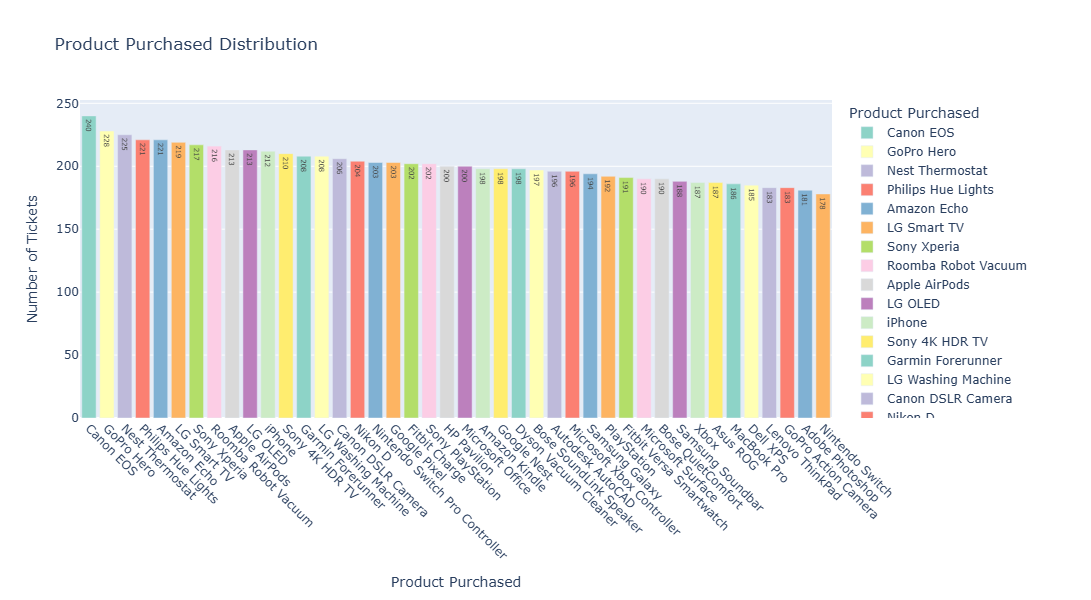

In [115]:
# Product distribution
product_dist = df['Product Purchased'].value_counts().reset_index()
product_dist.columns = ['Product Purchased', 'Count']

# Plot
fig = px.bar(
    product_dist,
    x='Product Purchased',
    y='Count',
    title='Product Purchased Distribution',
    text='Count',
    height=600,
    color='Product Purchased',
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(
    xaxis_title='Product Purchased',
    yaxis_title='Number of Tickets',
    xaxis_tickangle=45
)

fig.show()


In [116]:
# Chart 2: Top Items Purchased by Gender (Horizontal Bar Chart)
plt.figure(figsize=(15, 6))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

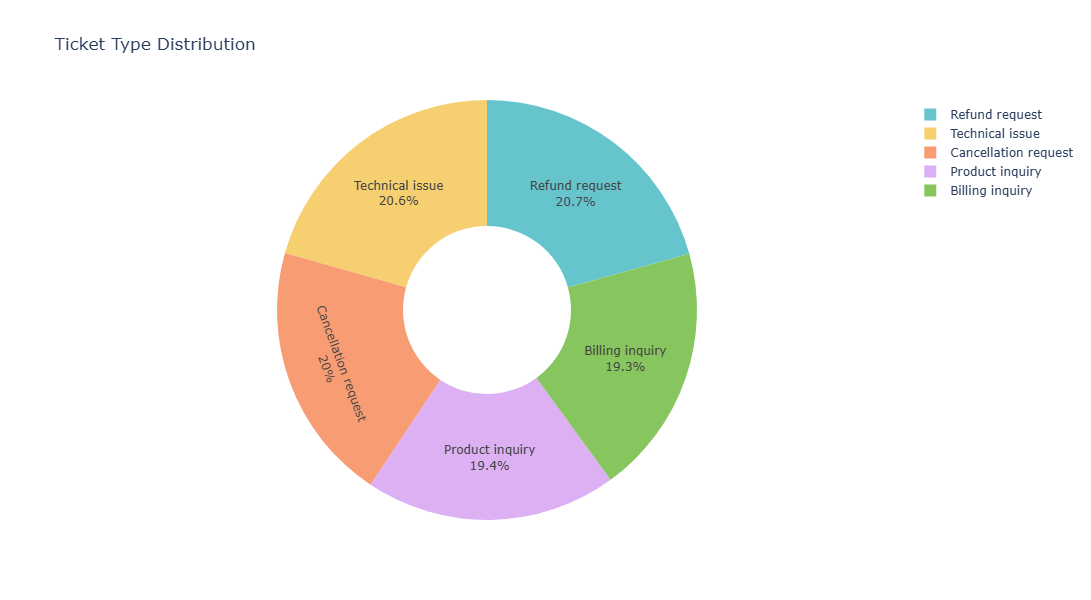

In [117]:
ticket_type_df = df['Ticket Type'].value_counts().reset_index()
ticket_type_df.columns = ['Ticket Type', 'Count']

fig = px.pie(
    ticket_type_df,
    names='Ticket Type',
    values='Count',
    title='Ticket Type Distribution',
    hole=0.4,
    height=600,
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textinfo='percent+label',hovertemplate='<b>%{label}</b><br>Tickets: %{value}<br>Percentage: %{percent}')

fig.show()


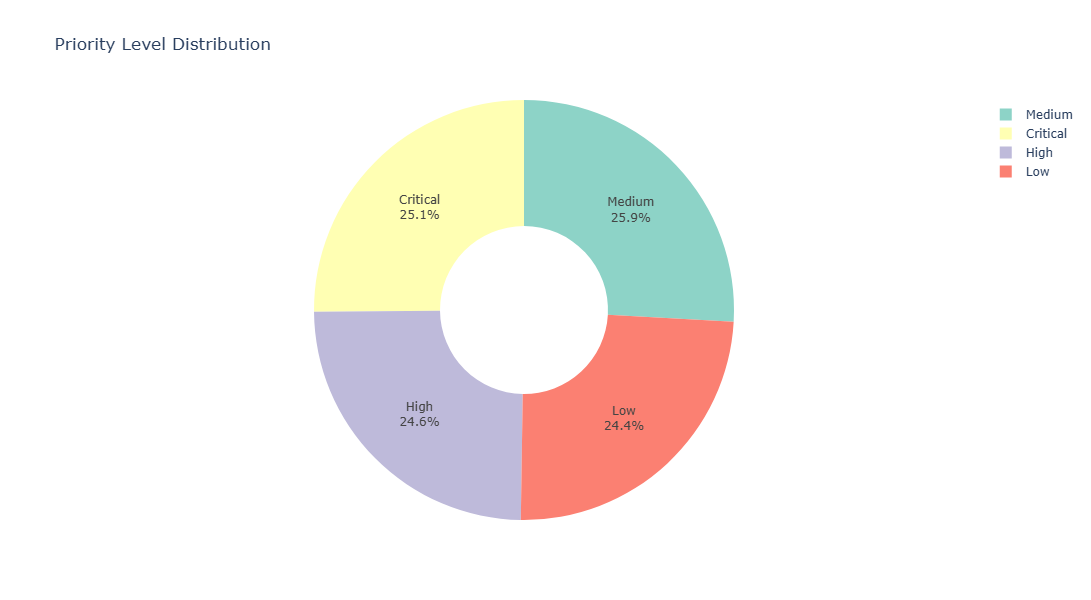

In [118]:
priority_df = df['Ticket Priority'].value_counts().reset_index()
priority_df.columns = ['Ticket Priority', 'Count']

fig = px.pie(
    priority_df,
    names='Ticket Priority',
    values='Count',
    title='Priority Level Distribution',
    hole=0.4,
    height=600,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>Tickets: %{value}<br>Percentage: %{percent}'
)

fig.show()


In [119]:
# Define age groups
bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '61-70','71-80', '81-90', '91-100']

# Create Age Group column
df['Age Group'] = pd.cut(
    df['Customer Age'],
    bins=bins,
    labels=labels,
    right=True
)

# Check result
df['Age Group'].value_counts().sort_index()


Age Group
0-20       505
21-30     1586
31-40     1541
41-50     1592
51-60     1675
61-70     1570
71-80        0
81-90        0
91-100       0
Name: count, dtype: int64

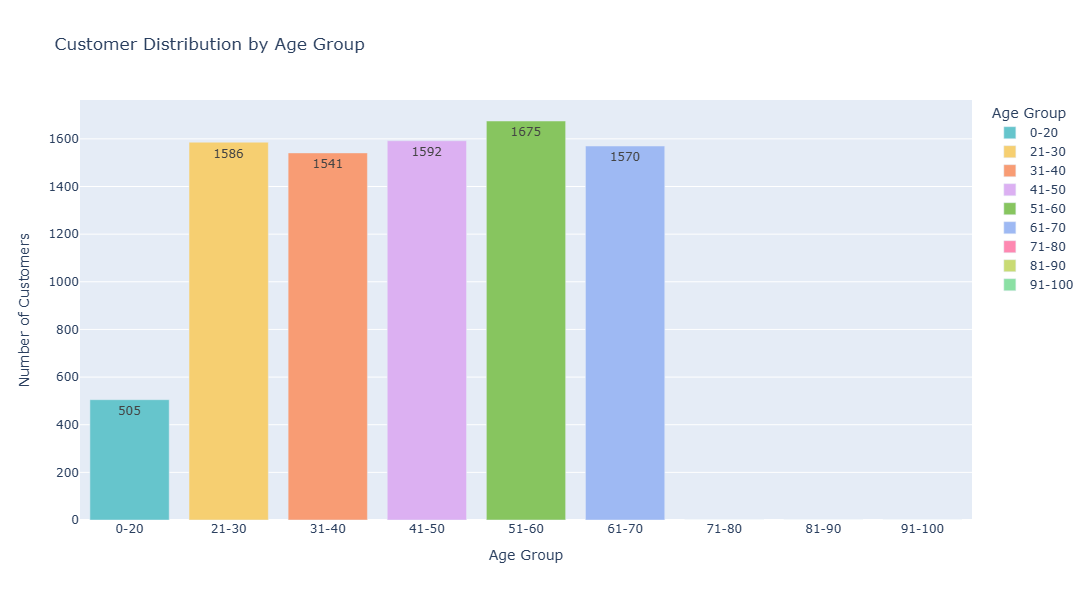

In [120]:
age_group_dist = (
    df['Age Group']
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_dist.columns = ['Age Group', 'Count']

fig = px.bar(
    age_group_dist,
    x='Age Group',
    y='Count',
    title='Customer Distribution by Age Group',
    text='Count',
    height=600,
    color='Age Group',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Number of Customers'
)

fig.show()


### Feature Engineering

In [121]:
data_fe = df.copy()

selected_categorical_cols = [
    'Customer Gender',
    'Product Purchased',
    'Ticket Type',
    'Ticket Status',
    'Ticket Priority',
    'Ticket Channel'
]

le = LabelEncoder()

for col in selected_categorical_cols:
    data_fe[col] = le.fit_transform(data_fe[col].astype(str))

data_fe.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,YearMonth,Age Group
0,1,Marisa Obrien,carrollallison@example.com,32,2,16,2021-03-22,4,Product setup,i'm having an issue with the {product_purchase...,2,Not Provided,0,3,19236.260000,-446928.0,3.0,2021-03-01,31-40
1,2,Jessica Rios,clarkeashley@example.com,42,0,21,2021-05-22,4,Peripheral compatibility,i'm having an issue with the {product_purchase...,2,Not Provided,0,0,17776.760556,-446928.0,3.0,2021-05-01,41-50
2,3,Christopher Robbins,gonzalestracy@example.com,48,2,10,2020-07-14,4,Network problem,i'm facing a problem with my {product_purchase...,0,Case maybe show recently my computer follow.,2,3,25259.243889,-442968.0,3.0,2020-07-01,41-50
3,4,Christina Dillon,bradleyolson@example.org,27,0,25,2020-11-13,0,Account access,i'm having an issue with the {product_purchase...,0,Try capital clearly never color toward story.,2,3,22327.494444,-445896.0,3.0,2020-11-01,21-30
4,5,Alexander Carroll,bradleymark@example.com,67,0,5,2020-02-04,0,Data loss,i'm having an issue with the {product_purchase...,0,West decision evidence bit.,2,1,29112.211667,-439104.0,1.0,2020-02-01,61-70


In [122]:
df['Customer Gender'] = (
    df['Customer Gender']
    .astype(str)
    .str.strip()
    .str.title()
)

df = df[df['Customer Gender'].isin(['Male', 'Female', 'Other'])]


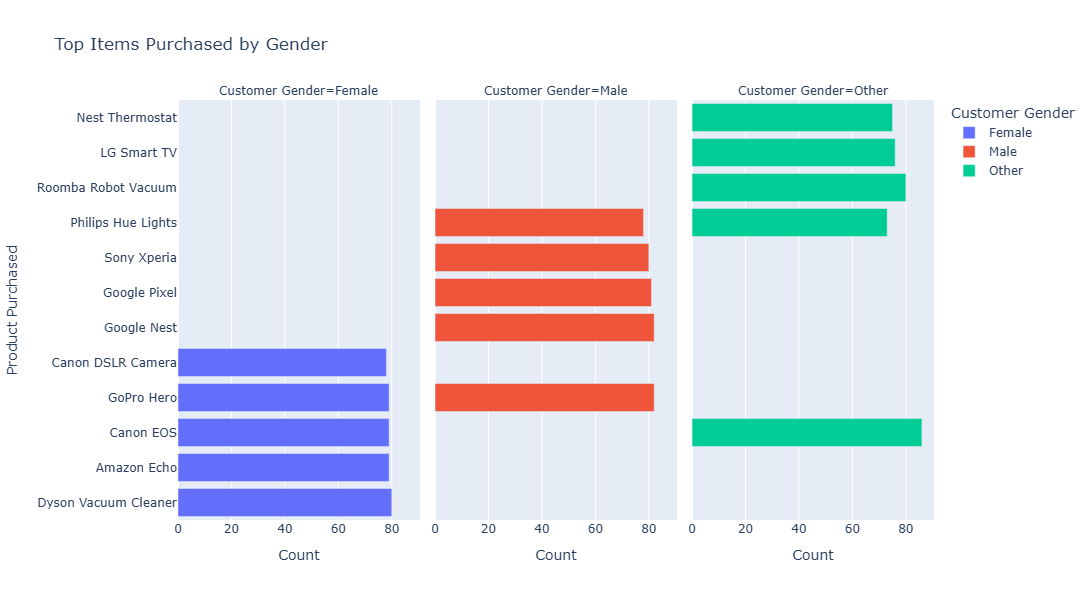

In [123]:

gender_product = (
    df.groupby(['Customer Gender', 'Product Purchased'])
    .size()
    .reset_index(name='Count')
)

top_gender_products = (
    gender_product
    .sort_values(['Customer Gender', 'Count'], ascending=[True, False])
    .groupby('Customer Gender')
    .head(5)
)

fig = px.bar(
    top_gender_products,
    x='Count',
    y='Product Purchased',
    color='Customer Gender',
    orientation='h',
    facet_col='Customer Gender',
    title='Top Items Purchased by Gender',
    height=600
)

fig.show()


In [148]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Create a clean copy for modeling
data_model = df.copy()

# Step 2: Drop irrelevant columns (identifiers)
data_model = data_model.drop(columns=[
    'Customer Name',
    'Customer Email',
    'Ticket Subject',
    'Ticket Description',
    'Resolution',
    'YearMonth'  
])

# Step 3: Convert 'Date of Purchase' to datetime and extract features
data_model['Date of Purchase'] = pd.to_datetime(data_model['Date of Purchase'])
data_model['Purchase_Year'] = data_model['Date of Purchase'].dt.year
data_model['Purchase_Month'] = data_model['Date of Purchase'].dt.month
data_model = data_model.drop(columns=['Date of Purchase'])

# Step 4: Clean 'Customer Gender' (strip, title case)
data_model['Customer Gender'] = data_model['Customer Gender'].astype(str).str.strip().str.title()

# Step 5: Define age groups
bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']
data_model['Age Group'] = pd.cut(data_model['Customer Age'], bins=bins, labels=labels, right=True)

# Step 6: Encode categorical columns
le = LabelEncoder()
categorical_cols = data_model.select_dtypes(include='object').columns
for col in categorical_cols:
    data_model[col] = le.fit_transform(data_model[col])

# Step 7: Encode Age Group (Ordinal)
data_model['Age Group'] = data_model['Age Group'].cat.codes

# Step 8: Define X and y
X = data_model.drop('Customer Satisfaction Rating', axis=1)
y = data_model['Customer Satisfaction Rating']

# Step 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 10: Check that all are numeric before scaling
print(X_train.select_dtypes(exclude=['int64', 'float64']).columns)

# Step 11: Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Index(['Age Group', 'Purchase_Year', 'Purchase_Month'], dtype='object')


### Model Building

Accuracy: 0.7426210153482881
Classification Report:
               precision    recall  f1-score   support

         1.0       0.23      0.13      0.17       115
         2.0       0.22      0.20      0.21       109
         3.0       0.87      0.94      0.90      1237
         4.0       0.35      0.24      0.28       126
         5.0       0.26      0.24      0.25       107

    accuracy                           0.74      1694
   macro avg       0.39      0.35      0.36      1694
weighted avg       0.71      0.74      0.72      1694

Confusion Matrix:
 [[  15   22   45   12   21]
 [  12   22   45   18   12]
 [  12   22 1165   16   22]
 [   7   20   50   30   19]
 [  18   15   38   10   26]]


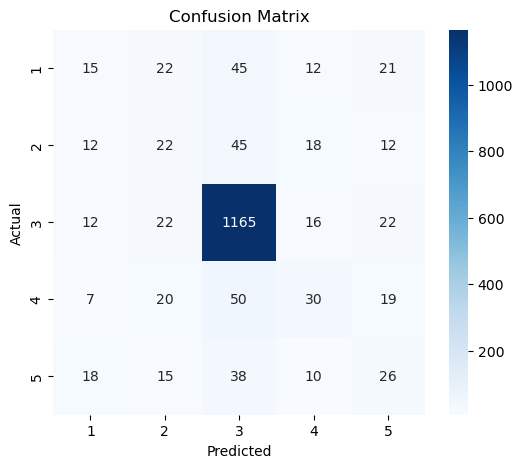

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step: Initialize and train the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Step: Make predictions
y_pred = model.predict(X_test)

# Step: Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step: Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 6), yticklabels=range(1, 6))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Random Forest Accuracy: 0.7278630460448642

Classification Report:
               precision    recall  f1-score   support

         1.0       0.21      0.21      0.21       115
         2.0       0.19      0.17      0.18       109
         3.0       0.90      0.93      0.92      1237
         4.0       0.23      0.17      0.20       126
         5.0       0.12      0.12      0.12       107

    accuracy                           0.73      1694
   macro avg       0.33      0.32      0.33      1694
weighted avg       0.71      0.73      0.72      1694


Confusion Matrix:
 [[  24   16   34   24   17]
 [  23   18   30   15   23]
 [  17   20 1156   19   25]
 [  26   20   30   22   28]
 [  24   20   36   14   13]]


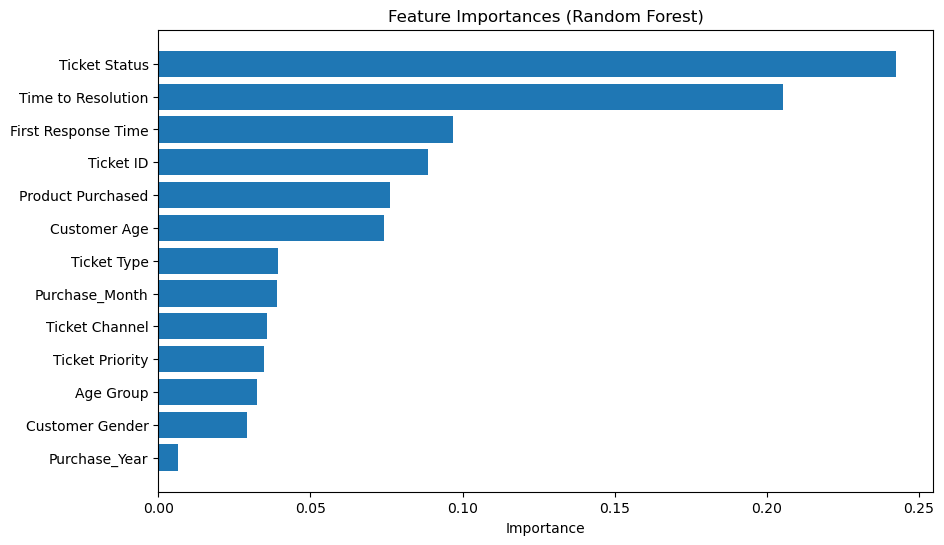

In [150]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step: Initialize and train the random forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step: Make predictions
y_pred_rf = rf_model.predict(X_test)

# Step: Evaluate model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Step: Plot feature importances
import matplotlib.pyplot as plt
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [152]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Cross-validation with 5 folds
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

# Print cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Cross-validation scores: [0.74557261 0.72491145 0.74025974 0.74025974 0.73656232]
Mean CV accuracy: 0.7375131714658106
Standard deviation: 0.006924583353461517


### MODEL EVALUATION

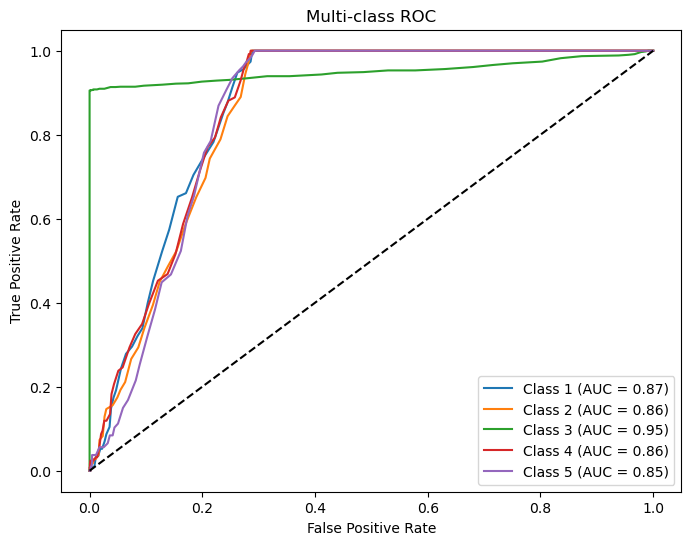

In [155]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output (since it's multiclass, we need a one-vs-rest format)
y_test_binarized = label_binarize(y_test, classes=[1, 2, 3, 4, 5])
n_classes = y_test_binarized.shape[1]

# Compute ROC AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], rf_model.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='Class {0} (AUC = {1:0.2f})'.format(i+1, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random chance
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc='lower right')
plt.show()

In [156]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Step 2: Set up GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_grid=param_grid,
                               cv=5,  # 5-fold cross-validation
                               scoring='accuracy',
                               n_jobs=-1,
                               verbose=2)

# Step 3: Fit GridSearch to data
grid_search.fit(X_train, y_train)

# Step 4: Best parameters and model
print("Best parameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# Step 5: Evaluate on test set
y_pred_rf = best_rf_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# Step 6: Cross-validation scores for the final model
cv_scores = cross_val_score(best_rf_model, X, y, cv=5, scoring='accuracy')
print("Final Model Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Test Accuracy: 0.7231404958677686
Classification Report:
               precision    recall  f1-score   support

         1.0       0.17      0.15      0.16       115
         2.0       0.20      0.17      0.18       109
         3.0       0.89      0.93      0.91      1237
         4.0       0.21      0.16      0.18       126
         5.0       0.14      0.14      0.14       107

    accuracy                           0.72      1694
   macro avg       0.32      0.31      0.31      1694
weighted avg       0.70      0.72      0.71      1694

Confusion Matrix:
 [[  17   15   39   22   22]
 [  23   18   29   16   23]
 [  15   24 1155   23   20]
 [  22   13   40   20   31]
 [  21   20   36   15   15]]
Final Model Cross-validation scores: [0.74498229 0.73140496 0.74498229 0.73494687 0.74246899]
Mean CV accuracy: 0.739757080164

## Visualization of Results and Feature Importance

C:\Users\VILLAYAT ALI\AppData\Local\Temp\ipykernel_11748\1046060450.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




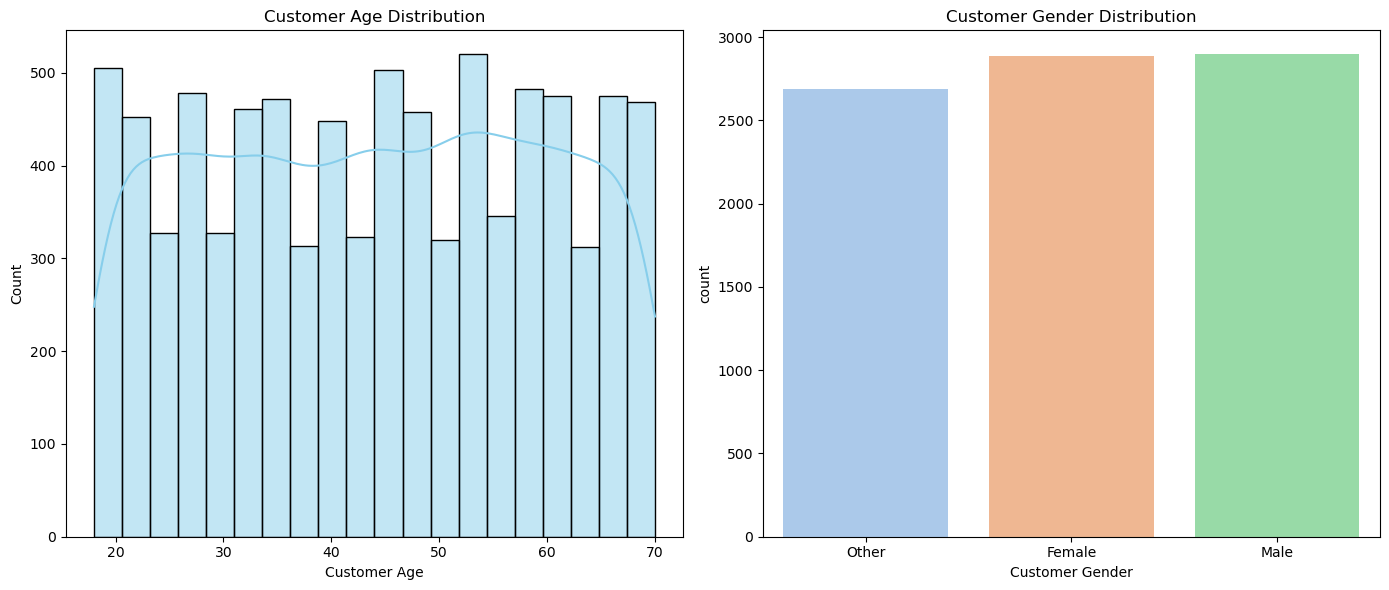

C:\Users\VILLAYAT ALI\AppData\Local\Temp\ipykernel_11748\1046060450.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




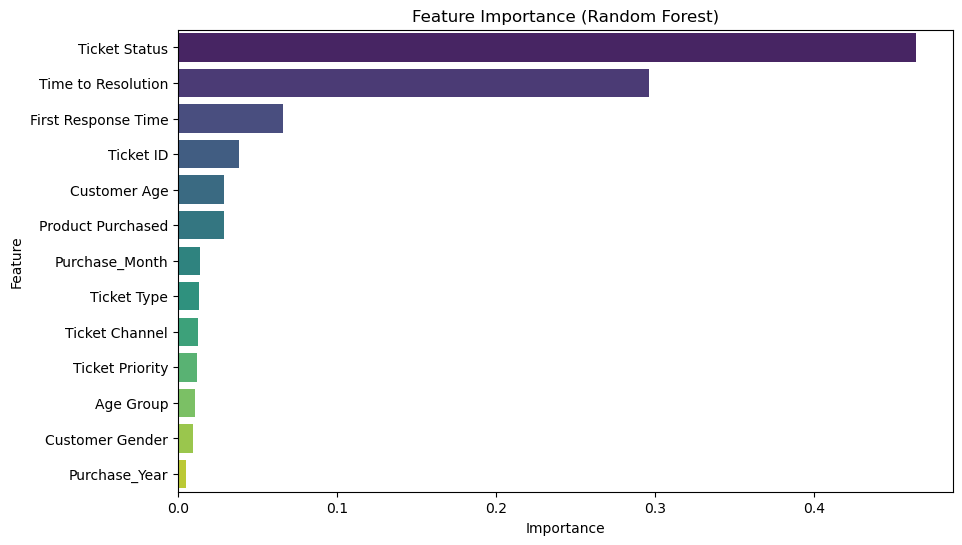

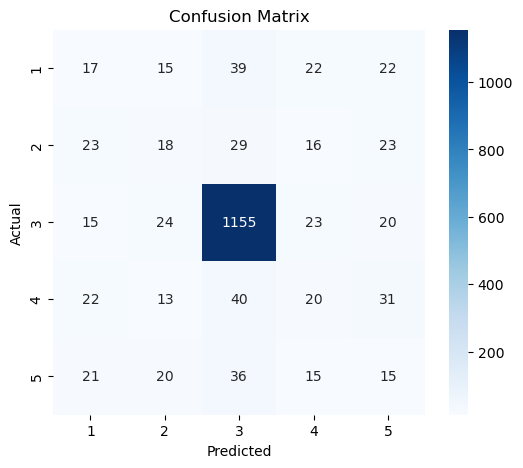

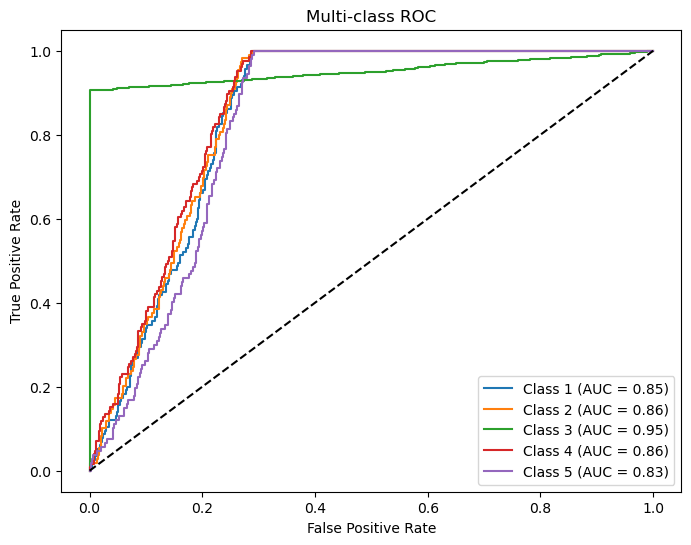

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Step 1: Visualize overall data distribution (e.g., Age, Gender distribution)
plt.figure(figsize=(14, 6))

# Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Customer Age'], bins=20, kde=True, color='skyblue')
plt.title('Customer Age Distribution')

# Gender Distribution
plt.subplot(1, 2, 2)
sns.countplot(x='Customer Gender', data=df, palette='pastel')
plt.title('Customer Gender Distribution')

plt.tight_layout()
plt.show()

# Step 2: Plot Feature Importance (from Random Forest model)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Step 3: Model Evaluation - Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 6), yticklabels=range(1, 6))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 4: Model Evaluation - ROC Curve (One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()
y_prob = best_rf_model.predict_proba(X_test)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='Class {0} (AUC = {1:0.2f})'.format(i+1, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC')
plt.legend(loc='lower right')
plt.show()

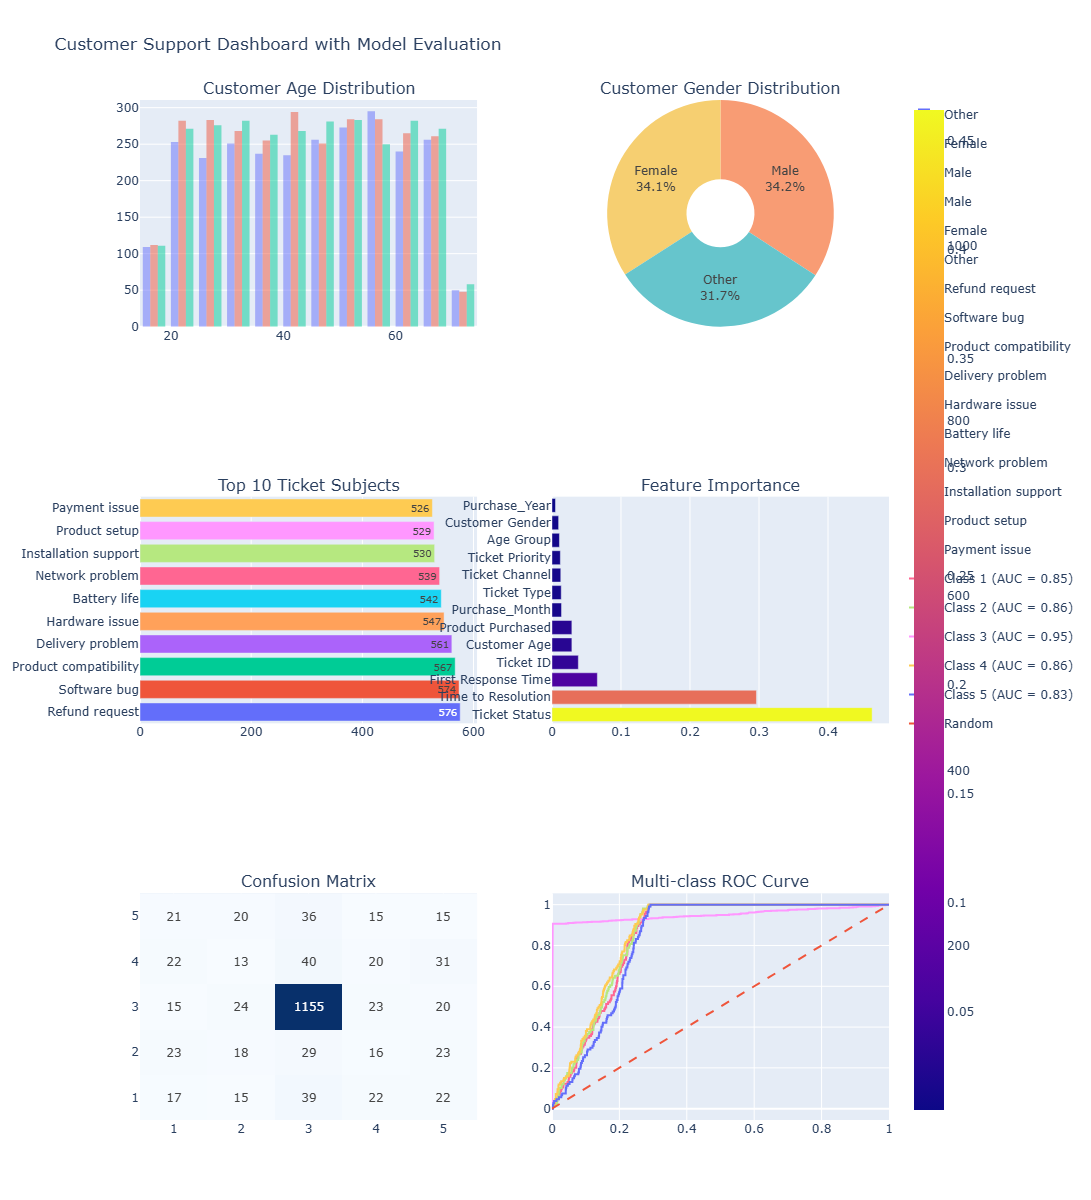

In [163]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ================================
# 1️⃣ Age Distribution
# ================================
fig_age = px.histogram(
    df,
    x='Customer Age',
    nbins=20,
    color='Customer Gender',
    barmode='overlay',
    title='Customer Age Distribution by Gender',
    labels={'Customer Age':'Age'},
    height=400
)

# ================================
# 2️⃣ Gender Distribution
# ================================
fig_gender = px.pie(
    df,
    names='Customer Gender',
    color='Customer Gender',
    title='Customer Gender Distribution',
    hole=0.3,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig_gender.update_traces(textinfo='percent+label')

# ================================
# 3️⃣ Top Ticket Subjects
# ================================
top_subjects = df['Ticket Subject'].value_counts().head(10).reset_index()
top_subjects.columns = ['Ticket Subject', 'Count']

fig_subject = px.bar(
    top_subjects,
    x='Count',
    y='Ticket Subject',
    color='Ticket Subject',
    orientation='h',
    title='Top 10 Ticket Subjects',
    text='Count',
    height=400
)

# ================================
# 4️⃣ Feature Importance (Random Forest)
# ================================
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

fig_importance = px.bar(
    feature_importance,
    x='Importance',
    y='Feature',
    color='Importance',
    orientation='h',
    title='Feature Importance (Random Forest)',
    height=400
)

# ================================
# 5️⃣ Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred_rf)
cm_fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=[str(i) for i in range(1,6)],
    y=[str(i) for i in range(1,6)],
    colorscale='Blues',
    hoverongaps=False,
    text=cm,
    texttemplate="%{text}"
))
cm_fig.update_layout(
    title='Confusion Matrix',
    xaxis_title='Predicted',
    yaxis_title='Actual',
    height=400
)

# ================================
# 6️⃣ Multi-class ROC Curve
# ================================
n_classes = y_test_binarized.shape[1]  # number of classes
fpr = dict()
tpr = dict()
roc_auc = dict()
y_prob = best_rf_model.predict_proba(X_test)

roc_fig = go.Figure()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    roc_fig.add_trace(go.Scatter(
        x=fpr[i],
        y=tpr[i],
        mode='lines',
        name=f'Class {i+1} (AUC = {roc_auc[i]:0.2f})'
    ))
roc_fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash')))
roc_fig.update_layout(
    title='Multi-class ROC Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=400
)

# ================================
# 7️⃣ Build Dashboard (3x2 Grid)
# ================================
dashboard = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'Customer Age Distribution',
        'Customer Gender Distribution',
        'Top 10 Ticket Subjects',
        'Feature Importance',
        'Confusion Matrix',
        'Multi-class ROC Curve'
    ),
    specs=[[{"type":"xy"},{"type":"domain"}],
           [{"type":"xy"},{"type":"xy"}],
           [{"type":"xy"},{"type":"xy"}]]
)

# Add traces
for trace in fig_age['data']:
    dashboard.add_trace(trace, row=1, col=1)
for trace in fig_gender['data']:
    dashboard.add_trace(trace, row=1, col=2)
for trace in fig_subject['data']:
    dashboard.add_trace(trace, row=2, col=1)
for trace in fig_importance['data']:
    dashboard.add_trace(trace, row=2, col=2)
dashboard.add_trace(cm_fig.data[0], row=3, col=1)
for trace in roc_fig.data:
    dashboard.add_trace(trace, row=3, col=2)

dashboard.update_layout(height=1200, showlegend=True, title_text="Customer Support Dashboard with Model Evaluation")
dashboard.show()